<a href="https://colab.research.google.com/github/Kanabee/customer-segmentation/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importing the Libraries
import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import metrics

In [ ]:
#download data
!gdown 'https://drive.google.com/uc?id=1ky87luZzKgZk2yJPMxZkM6QMPZKRJXrP' -O marketing_campaign.csv

Downloading...
From: https://drive.google.com/uc?id=1ky87luZzKgZk2yJPMxZkM6QMPZKRJXrP
To: /content/marketing_campaign.csv
100% 220k/220k [00:00<00:00, 20.8MB/s]


In [ ]:
#Loading the dataset
data = pd.read_csv("/content/marketing_campaign.csv", sep="\t")
print("Number of datapoints:", len(data))
data.head()

Number of datapoints: 2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
#People
data[['ID','Year_Birth','Education','Marital_Status','Income','Kidhome','Teenhome','Dt_Customer','Recency','Complain']]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,Complain
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,0
...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,0


In [ ]:
#Products
data[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']]

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,635,88,546,172,88,88
1,11,1,6,2,1,6
2,426,49,127,111,21,42
3,11,4,20,10,3,5
4,173,43,118,46,27,15
...,...,...,...,...,...,...
2235,709,43,182,42,118,247
2236,406,0,30,0,0,8
2237,908,48,217,32,12,24
2238,428,30,214,80,30,61


In [ ]:
#Promotion
data[['NumDealsPurchases','AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']]

,NumDealsPurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
0,3,0,0,0,0,0,1
1,2,0,0,0,0,0,0
2,1,0,0,0,0,0,0
3,2,0,0,0,0,0,0
4,5,0,0,0,0,0,0
...,...,...,...,...,...,...,...
2235,2,0,0,0,0,0,0
2236,7,1,0,0,0,0,0
2237,1,0,0,0,1,0,0
2238,2,0,0,0,0,0,0


In [ ]:
#Place
data[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth']]

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,8,10,4,7
1,1,1,2,5
2,8,2,10,4
3,2,0,4,6
4,5,3,6,5
...,...,...,...,...
2235,9,3,4,5
2236,8,2,5,7
2237,2,3,13,6
2238,6,5,10,3


In [ ]:
#Information on features
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
#To remove the NA values
data = data.dropna()
print("The total number of data-points after removing the rows with missing values are:", len(data))

The total number of data-points after removing the rows with missing values are: 2216


In [ ]:
data["Dt_Customer"] = pd.to_datetime(
    data["Dt_Customer"],
    format="%d-%m-%Y"
)

dates = []

for i in data["Dt_Customer"]:
    i = i.date()
    dates.append(i)

print("The newest customer's enrolment date in the records:", max(dates))
print("The oldest customer's enrolment date in the records:", min(dates))

The newest customer's enrolment date in the records: 2014-06-29
The oldest customer's enrolment date in the records: 2012-07-30


In [ ]:
dates[:10]

[datetime.date(2012, 9, 4),
 datetime.date(2014, 3, 8),
 datetime.date(2013, 8, 21),
 datetime.date(2014, 2, 10),
 datetime.date(2014, 1, 19),
 datetime.date(2013, 9, 9),
 datetime.date(2012, 11, 13),
 datetime.date(2013, 5, 8),
 datetime.date(2013, 6, 6),
 datetime.date(2014, 3, 13)]

Creating a feature ("Customer_For") of the number of days the customers started to shop in the store relative to the last recorded date

In [ ]:
#Created a feature "Customer_For"
days = []
d1 = max(dates) #taking it to be the newest customer
for i in dates:
    delta = d1 - i
    days.append(delta)

In [ ]:
days[:10]

[datetime.timedelta(days=663),
 datetime.timedelta(days=113),
 datetime.timedelta(days=312),
 datetime.timedelta(days=139),
 datetime.timedelta(days=161),
 datetime.timedelta(days=293),
 datetime.timedelta(days=593),
 datetime.timedelta(days=417),
 datetime.timedelta(days=388),
 datetime.timedelta(days=108)]

In [ ]:
data["Customer_For"] = days

In [ ]:
data["Customer_For"]

,Customer_For
0,663 days
1,113 days
2,312 days
3,139 days
4,161 days
...,...
2235,381 days
2236,19 days
2237,155 days
2238,156 days


In [ ]:
data["Customer_For"] = pd.to_numeric(data["Customer_For"], errors="coerce")

In [ ]:
data["Customer_For"]

,Customer_For
0,57283200000000000
1,9763200000000000
2,26956800000000000
3,12009600000000000
4,13910400000000000
...,...
2235,32918400000000000
2236,1641600000000000
2237,13392000000000000
2238,13478400000000000


In [ ]:
print("Total categories in the feature Marital_Status:\n", data["Marital_Status"].value_counts(), "\n")
print("Total categories in the feature Education:\n", data["Education"].value_counts())

Total categories in the feature Marital_Status:
 Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Total categories in the feature Education:
 Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64


In [ ]:
#Feature Engineering
#Age of customer today
data["Age"] = 2022-data["Year_Birth"]

#Total spendings on various items
data["Spent"] = data["MntWines"]+ data["MntFruits"]+ data["MntMeatProducts"]+ data["MntFishProducts"]+ data["MntSweetProducts"]+ data["MntGoldProds"]

#Deriving living situation by marital status"Alone"
data["Living_With"]=data["Marital_Status"].replace({"Married":"Partner", "Together":"Partner", "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone", "Divorced":"Alone", "Single":"Alone",})

#Feature indicating total children living in the household
data["Children"]=data["Kidhome"]+data["Teenhome"]

#Feature for total members in the householde
data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner":2})+ data["Children"]

#Feature pertaining parenthood
data["Is_Parent"] = np.where(data.Children> 0, 1, 0)

#Segmenting education levels in three groups
data["Education"]=data["Education"].replace({"Basic":"Undergraduate","2n Cycle":"Undergraduate", "Graduation":"Graduate", "Master":"Postgraduate", "PhD":"Postgraduate"})

#For clarity
data=data.rename(columns={"MntWines": "Wines","MntFruits":"Fruits","MntMeatProducts":"Meat","MntFishProducts":"Fish","MntSweetProducts":"Sweets","MntGoldProds":"Gold"})

#Dropping some of the redundant features
to_drop = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"]
data = data.drop(to_drop, axis=1)

/tmp/ipykernel_3326/2608513278.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner":2})+ data["Children"]


In [ ]:
data.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Children,Family_Size,Is_Parent
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2.216000e+03,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,...,0.064079,0.013538,0.009477,0.150271,3.054423e+16,53.179603,607.075361,0.947202,2.592509,0.714350
std,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,...,0.244950,0.115588,0.096907,0.357417,1.749036e+16,11.985554,602.900476,0.749062,0.905722,0.451825
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,26.000000,5.000000,0.000000,1.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,1.555200e+16,45.000000,69.000000,0.000000,2.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,...,0.000000,0.000000,0.000000,0.000000,3.071520e+16,52.000000,396.500000,1.000000,3.000000,1.000000
75%,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,...,0.000000,0.000000,0.000000,0.000000,4.570560e+16,63.000000,1048.000000,1.000000,3.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,6.039360e+16,129.000000,2525.000000,3.000000,5.000000,1.000000


Reletive Plot Of Some Selected Features: A Data Subset


<Figure size 800x550 with 0 Axes>

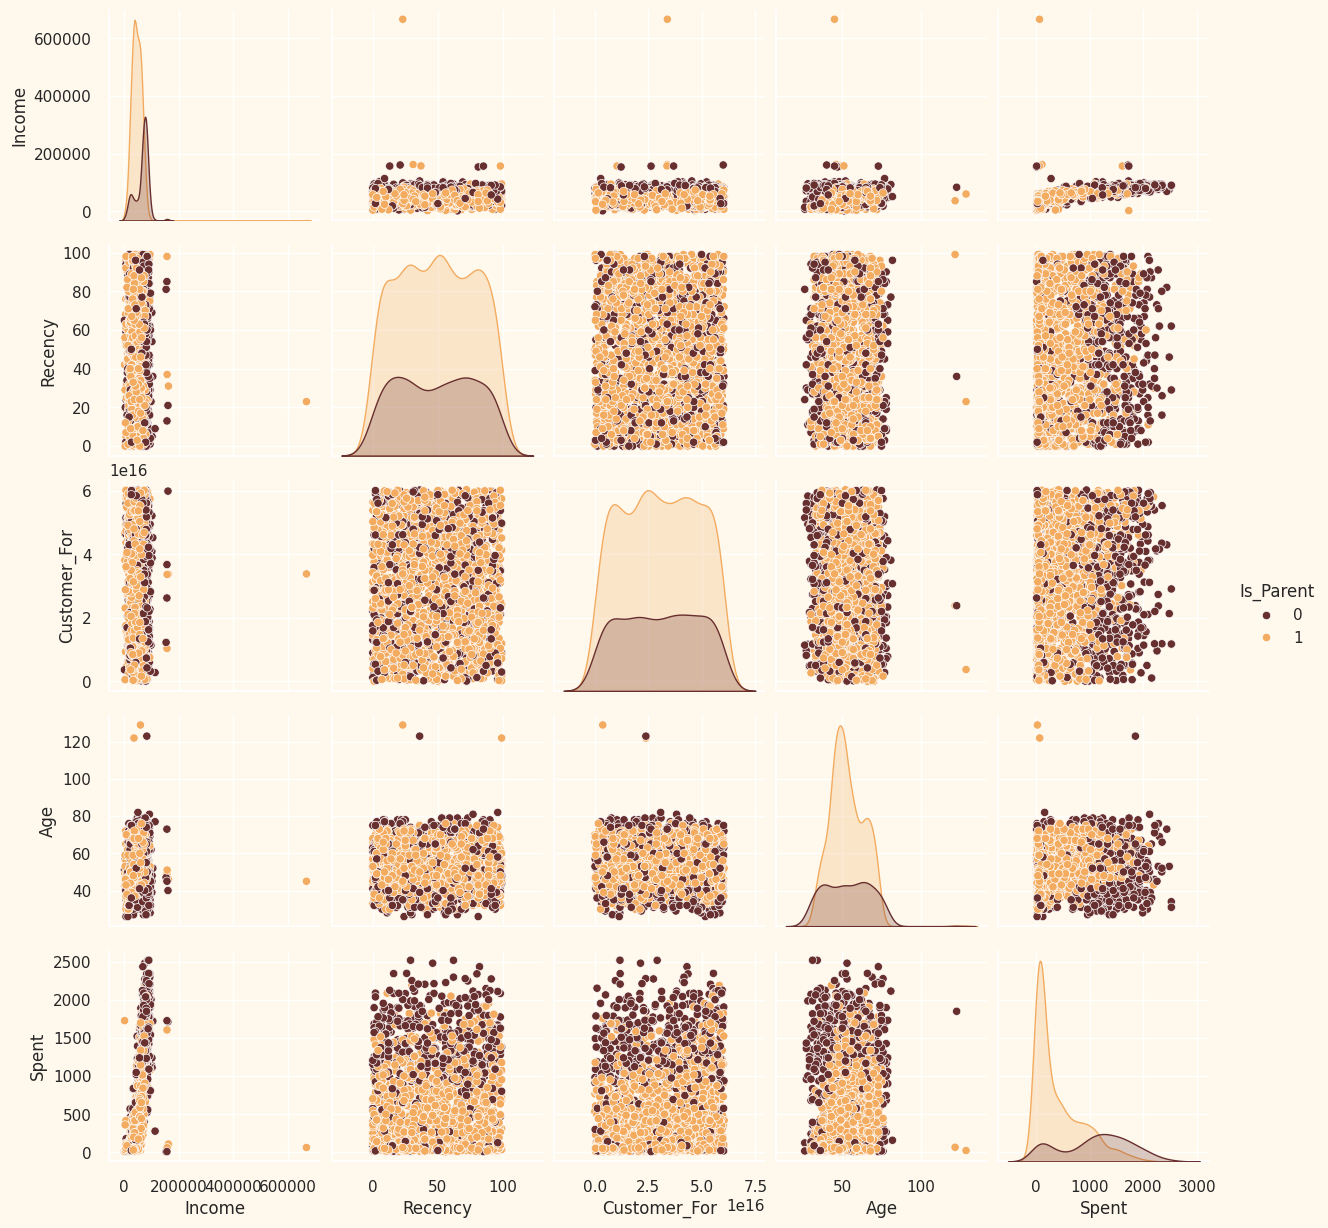

In [ ]:
#To plot some selected features
#Setting up colors prefrences
sns.set(rc={"axes.facecolor":"#FFF9ED","figure.facecolor":"#FFF9ED"})
pallet = ["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"]
cmap = colors.ListedColormap(["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"])
#Plotting following features
To_Plot = [ "Income", "Recency", "Customer_For", "Age", "Spent", "Is_Parent"]
print("Reletive Plot Of Some Selected Features: A Data Subset")
plt.figure()
sns.pairplot(data[To_Plot], hue= "Is_Parent",palette= (["#682F2F","#F3AB60"]))
#Taking hue
plt.show()

In [ ]:
#Dropping the outliers by setting a cap on Age and income.
data = data[(data["Age"]<90)]
data = data[(data["Income"]<600000)]
print("The total number of data-points after removing the outliers are:", len(data))

The total number of data-points after removing the outliers are: 2212


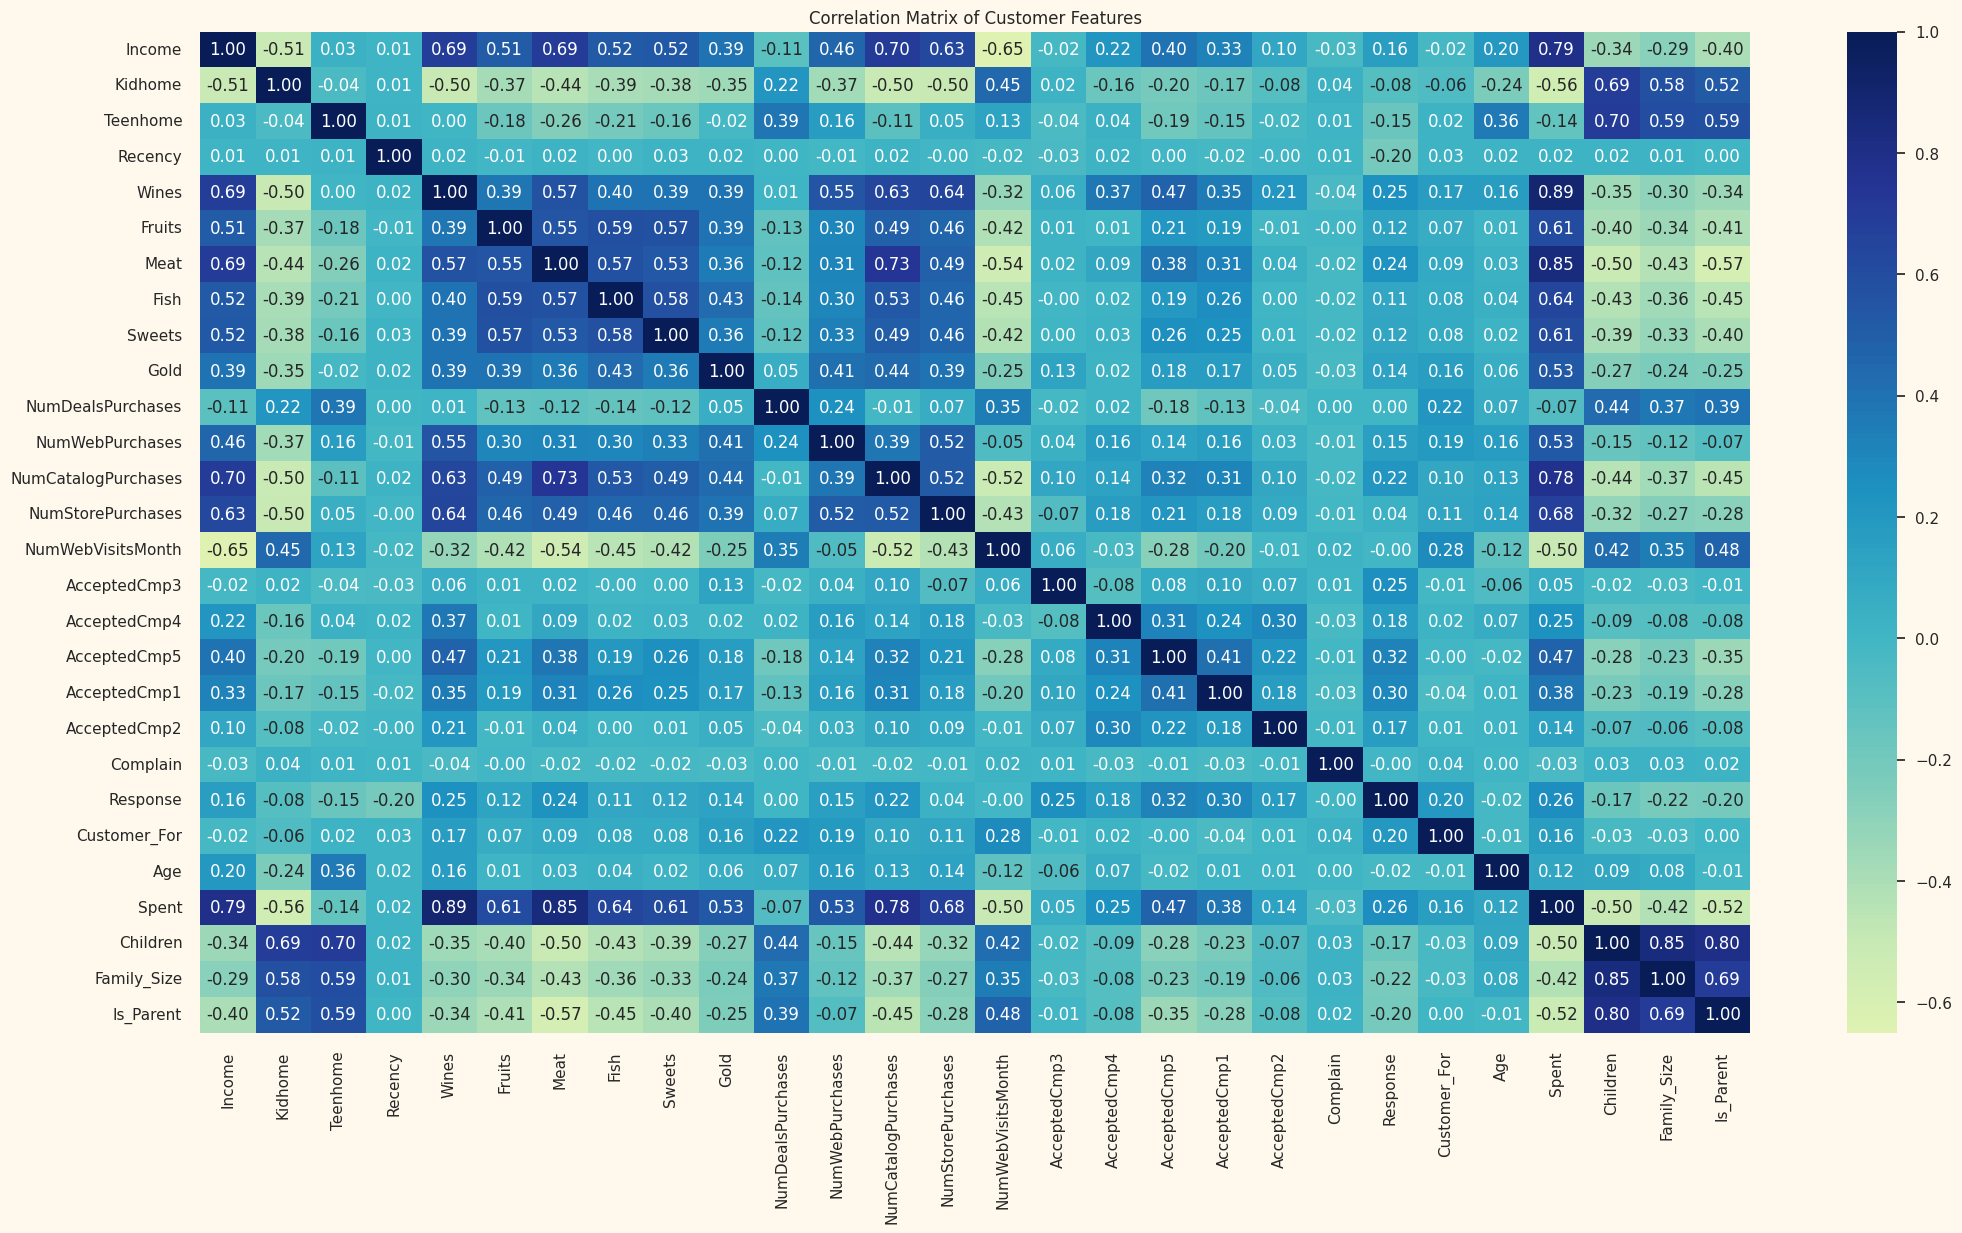

In [ ]:
# Correlation matrix - numeric features only
numeric_data = data.select_dtypes(include='number')

corrmat = numeric_data.corr()

plt.figure(figsize=(25, 13))
sns.heatmap(
    corrmat,
    annot=True,
    center=0,
    cmap='YlGnBu',
    fmt='.2f'
)

plt.title('Correlation Matrix of Customer Features')
plt.show()

DATA PREPROCESSING

In [ ]:
#Get list of categorical variables
s = (data.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables in the dataset:", object_cols)

Categorical variables in the dataset: ['Education', 'Living_With']


In [ ]:
data[['Living_With','Education']]

,Living_With,Education
0,Alone,Graduate
1,Alone,Graduate
2,Partner,Graduate
3,Partner,Graduate
4,Partner,Postgraduate
...,...,...
2235,Partner,Graduate
2236,Partner,Postgraduate
2237,Alone,Graduate
2238,Partner,Postgraduate


In [ ]:
#Label Encoding the object dtypes.
LE=LabelEncoder()
for i in object_cols:
    data[i]=data[[i]].apply(LE.fit_transform)

print("All features are now numerical")

All features are now numerical


In [ ]:
data[['Living_With','Education']]

,Living_With,Education
0,0,0
1,0,0
2,1,0
3,1,0
4,1,1
...,...,...
2235,1,0
2236,1,1
2237,0,0
2238,1,1


In [ ]:
#Creating a copy of data
ds = data.copy()
# creating a subset of dataframe by dropping the features on deals accepted and promotions
cols_del = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2', 'Complain', 'Response']
ds = ds.drop(cols_del, axis=1)

In [ ]:
ds

,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent
0,0,58138.0,0,0,58,635,88,546,172,88,...,10,4,7,57283200000000000,65,1617,0,0,1,0
1,0,46344.0,1,1,38,11,1,6,2,1,...,1,2,5,9763200000000000,68,27,0,2,3,1
2,0,71613.0,0,0,26,426,49,127,111,21,...,2,10,4,26956800000000000,57,776,1,0,2,0
3,0,26646.0,1,0,26,11,4,20,10,3,...,0,4,6,12009600000000000,38,53,1,1,3,1
4,1,58293.0,1,0,94,173,43,118,46,27,...,3,6,5,13910400000000000,41,422,1,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,0,61223.0,0,1,46,709,43,182,42,118,...,3,4,5,32918400000000000,55,1341,1,1,3,1
2236,1,64014.0,2,1,56,406,0,30,0,0,...,2,5,7,1641600000000000,76,444,1,3,5,1
2237,0,56981.0,0,0,91,908,48,217,32,12,...,3,13,6,13392000000000000,41,1241,0,0,1,0
2238,1,69245.0,0,1,8,428,30,214,80,30,...,5,10,3,13478400000000000,66,843,1,1,3,1


In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   int64  
 1   Income               2212 non-null   float64
 2   Kidhome              2212 non-null   int64  
 3   Teenhome             2212 non-null   int64  
 4   Recency              2212 non-null   int64  
 5   Wines                2212 non-null   int64  
 6   Fruits               2212 non-null   int64  
 7   Meat                 2212 non-null   int64  
 8   Fish                 2212 non-null   int64  
 9   Sweets               2212 non-null   int64  
 10  Gold                 2212 non-null   int64  
 11  NumDealsPurchases    2212 non-null   int64  
 12  NumWebPurchases      2212 non-null   int64  
 13  NumCatalogPurchases  2212 non-null   int64  
 14  NumStorePurchases    2212 non-null   int64  
 15  NumWebVisitsMonth    2212 non-null   int64 

In [ ]:
#Scaling
scaler = StandardScaler()
scaler.fit(ds)
scaled_ds = pd.DataFrame(scaler.transform(ds),columns= ds.columns )
scaled_ds

,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent
0,-0.893586,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,...,2.503607,-0.555814,0.692181,1.527721,1.018352,1.676245,-1.349603,-1.264598,-1.758359,-1.581139
1,-0.893586,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,...,-0.571340,-1.171160,-0.132545,-1.189011,1.274785,-0.963297,-1.349603,1.404572,0.449070,0.632456
2,-0.893586,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,...,-0.229679,1.290224,-0.544908,-0.206048,0.334530,0.280110,0.740959,-1.264598,-0.654644,-1.581139
3,-0.893586,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,...,-0.913000,-0.555814,0.279818,-1.060584,-1.289547,-0.920135,0.740959,0.069987,0.449070,0.632456
4,0.571657,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,...,0.111982,0.059532,-0.132545,-0.951915,-1.033114,-0.307562,0.740959,0.069987,0.449070,0.632456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2207,-0.893586,0.430444,-0.822754,0.908097,-0.104347,1.197084,0.419540,0.066770,0.079461,2.213965,...,0.111982,-0.555814,-0.132545,0.134778,0.163575,1.218061,0.740959,0.069987,0.449070,0.632456
2208,0.571657,0.560123,2.902796,0.908097,0.241237,0.298631,-0.662628,-0.611184,-0.687527,-0.658360,...,-0.229679,-0.248141,0.692181,-1.653326,1.958607,-0.271040,0.740959,2.739158,2.656499,0.632456
2209,-0.893586,0.233347,-0.822754,-0.929699,1.450778,1.787156,0.545373,0.222878,-0.103155,-0.366260,...,0.111982,2.213242,0.279818,-0.981552,-1.033114,1.052052,-1.349603,-1.264598,-1.758359,-1.581139
2210,0.571657,0.803172,-0.822754,0.908097,-1.417564,0.363866,0.092373,0.209498,0.773403,0.071892,...,0.795303,1.290224,-0.957271,-0.976612,1.103830,0.391336,0.740959,0.069987,0.449070,0.632456


In [ ]:
scaled_ds.describe()

,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent
count,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,...,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03
mean,1.445498e-17,-1.252765e-16,4.175884e-17,9.636656e-17,4.015273e-18,4.898633e-17,1.043971e-17,3.212219e-18,-1.204582e-17,3.212219e-18,...,-8.672990e-17,-7.107033e-17,1.092154e-16,9.797266e-17,6.183521e-17,5.942604e-17,-2.730386e-17,2.248553e-17,2.505530e-16,1.606109e-17
std,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,...,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00
min,-8.935862e-01,-2.333791e+00,-8.227535e-01,-9.296987e-01,-1.694030e+00,-9.052351e-01,-6.626279e-01,-7.449911e-01,-6.875269e-01,-6.583604e-01,...,-9.130004e-01,-1.786506e+00,-2.194360e+00,-1.747176e+00,-2.315280e+00,-9.998189e-01,-1.349603e+00,-1.264598e+00,-1.758359e+00,-1.581139e+00
25%,-8.935862e-01,-7.771113e-01,-8.227535e-01,-9.296987e-01,-8.646302e-01,-8.340705e-01,-6.122946e-01,-6.736275e-01,-6.327421e-01,-6.340186e-01,...,-9.130004e-01,-8.634873e-01,-9.572709e-01,-8.580640e-01,-6.912026e-01,-8.935732e-01,-1.349603e+00,-1.264598e+00,-6.546443e-01,-1.581139e+00
50%,-8.935862e-01,-2.731156e-02,-8.227535e-01,-9.296987e-01,-6.717941e-04,-3.848445e-01,-4.612945e-01,-4.416956e-01,-4.683875e-01,-4.636265e-01,...,-2.296788e-01,-2.481413e-01,2.798177e-01,1.129032e-02,-9.285849e-02,-3.490638e-01,7.409586e-01,6.998729e-02,4.490700e-01,6.324555e-01
75%,5.716567e-01,7.679525e-01,1.040021e+00,9.080971e-01,8.632866e-01,5.921851e-01,1.678727e-01,2.908968e-01,2.255541e-01,1.449170e-01,...,4.536427e-01,6.748776e-01,6.921805e-01,8.658261e-01,8.473966e-01,7.316544e-01,7.409586e-01,6.998729e-02,4.490700e-01,6.324555e-01
max,2.036900e+00,5.131311e+00,2.902796e+00,2.745893e+00,1.727245e+00,3.521791e+00,4.345543e+00,6.948902e+00,4.042233e+00,5.719175e+00,...,8.653501e+00,2.213242e+00,6.052898e+00,1.705543e+00,2.471473e+00,3.183607e+00,7.409586e-01,2.739158e+00,2.656499e+00,6.324555e-01


CLUSTERING

Elbow Method to determine the number of clusters to be formed:


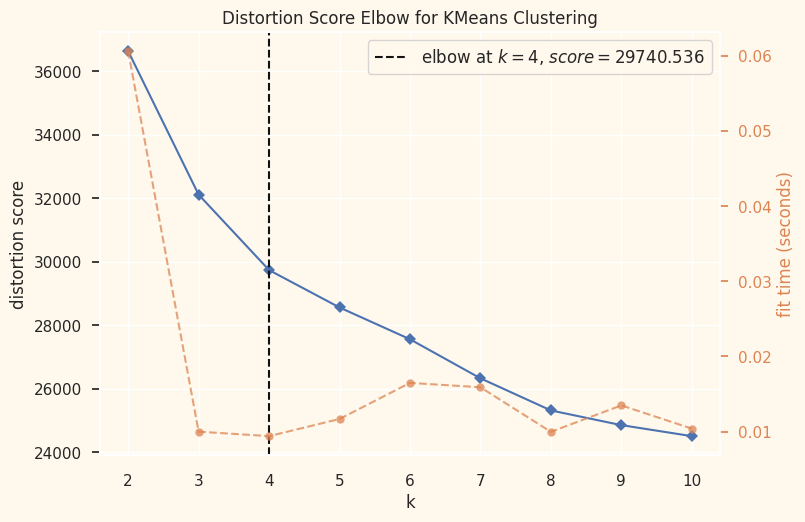

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Quick examination of elbow method to find numbers of clusters to make.
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(), k=10)
Elbow_M.fit(scaled_ds)
Elbow_M.show()

### Selecting the Number of Clusters

The Elbow Method was used to determine the appropriate number of customer segments. Based on the distortion curve, **4 clusters** were selected for the K-Means model.

In [ ]:
#Initiating the Agglomerative Clustering model
km = KMeans(n_clusters=4, random_state=0)
# fit model and predict clusters
yhat_km = km.fit_predict(scaled_ds)
scaled_ds["Clusters"] = yhat_km
#Adding the Clusters feature to the orignal dataframe.
data["Clusters"]= yhat_km

EVALUATING MODELS

/tmp/ipykernel_3326/1397449635.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl = sns.countplot(x=data["Clusters"], palette= pal)


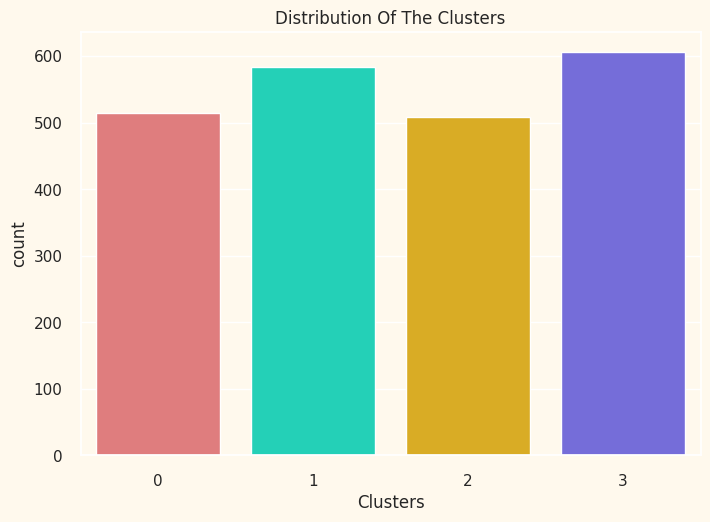

In [ ]:
#Plotting countplot of clusters
pal = ["#f06c6e","#07edcb", "#f7bb07","#655beb"]
pl = sns.countplot(x=data["Clusters"], palette= pal)
pl.set_title("Distribution Of The Clusters")
plt.show()

### Cluster Distribution

The four customer segments are relatively balanced in size, allowing meaningful comparison of customer characteristics and purchasing behavior across groups.

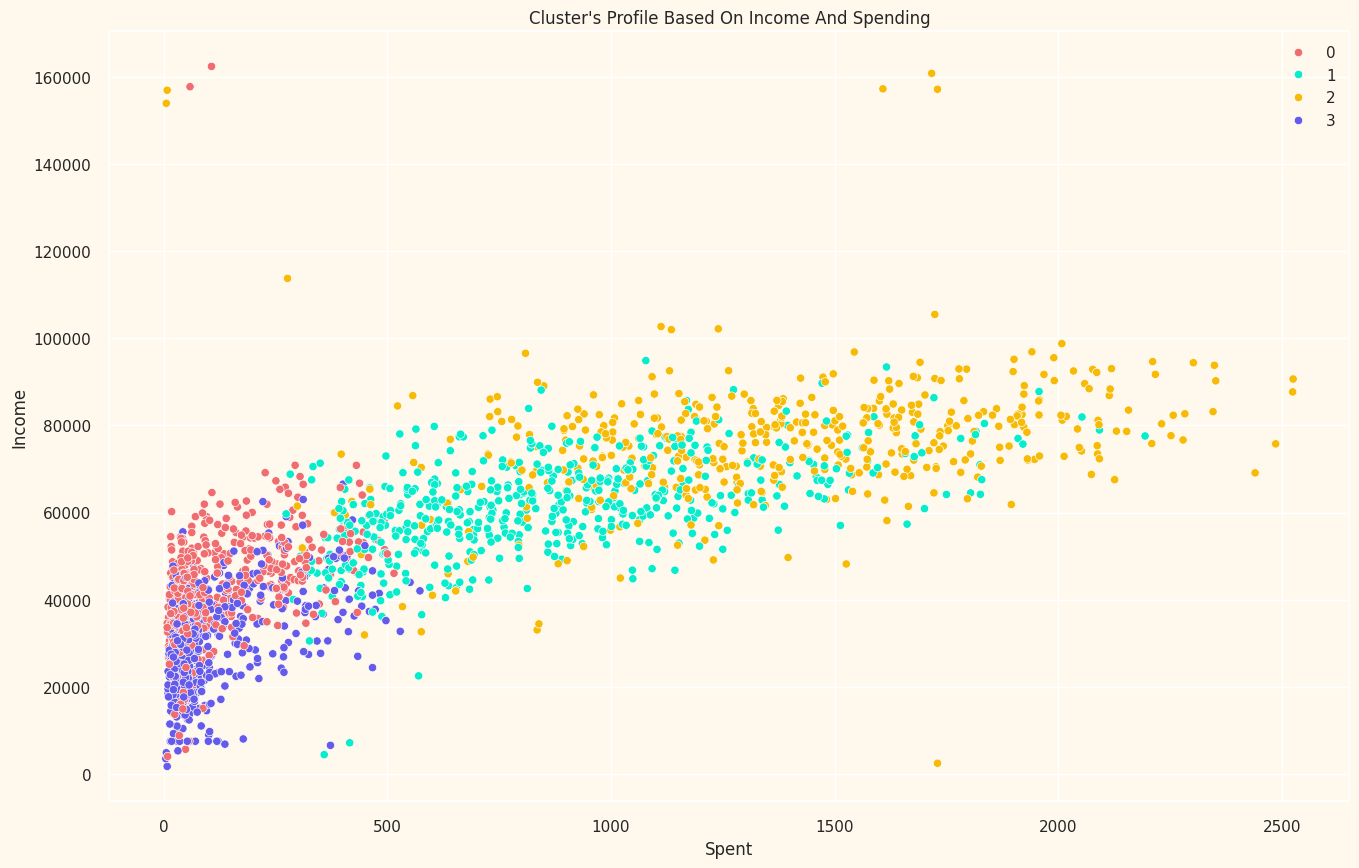

In [ ]:
plt.figure(figsize = (16,10))
pl = sns.scatterplot(data = data,x=data["Spent"], y=data["Income"],hue=data["Clusters"], palette= pal)
pl.set_title("Cluster's Profile Based On Income And Spending")
plt.legend()
plt.show()

In [ ]:
# Customer profile summary by cluster

cluster_profile = data.groupby("Clusters")[
    [
        "Income",
        "Spent",
        "Age",
        "Children",
        "Family_Size",
        "NumDealsPurchases",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases",
        "NumWebVisitsMonth"
    ]
].mean().round(2)

cluster_profile

,Income,Spent,Age,Children,Family_Size,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
Clusters,,,,,,,,,,
0,42738.15,135.58,57.59,1.83,3.53,2.76,2.51,0.77,3.65,6.06
1,61795.20,874.93,56.59,1.13,2.80,3.45,6.60,3.67,8.29,5.42
2,76135.86,1371.03,53.86,0.03,1.62,1.13,4.94,5.98,8.23,2.65
3,30009.45,108.34,45.25,0.79,2.42,1.88,2.29,0.55,3.22,6.85


### Customer Segment Profiles

**Cluster 0 — Family-Oriented Low-Spending Customers**
- Medium income with relatively low spending
- Largest family size and highest number of children
- Potentially more price-sensitive and family-focused

**Cluster 1 — Active Mid-to-High Value Customers**
- Mid-to-high income with high spending
- Highly active across web and store channels
- Highest usage of promotional deals

**Cluster 2 — High-Value Customers**
- Highest average income and spending
- Strong catalog and store purchasing behavior
- Very few children and smaller households
- Strong potential for premium and loyalty campaigns

**Cluster 3 — Low-Value / Low-Engagement Customers**
- Lowest average income and spending
- High website visits but relatively low purchasing activity
- Potential opportunity to improve conversion through targeted offers

## Business Recommendations

Based on the customer segmentation results, different marketing strategies can be applied to each customer group.

### Cluster 0 — Family-Oriented Low-Spending Customers
- Offer family bundles and value-for-money packages.
- Use discounts and family-focused promotions to encourage higher spending.
- Recommend products that match larger household needs.

### Cluster 1 — Active Mid-to-High Value Customers
- Use cross-channel campaigns across web and physical stores.
- Provide loyalty rewards and personalized promotions.
- Apply upselling and cross-selling strategies to increase customer value.

### Cluster 2 — High-Value Customers
- Prioritize customer retention through VIP or loyalty programs.
- Recommend premium products and personalized offers.
- Provide exclusive campaigns to maintain engagement with these high-value customers.

### Cluster 3 — Low-Value / Low-Engagement Customers
- Focus on converting website visits into purchases.
- Test targeted discounts or entry-level offers.
- Use retargeting campaigns for customers who visit frequently but purchase less.

## Business Impact

Customer segmentation allows the business to move away from a one-size-fits-all marketing strategy.

By understanding differences in customer income, spending behavior, household characteristics, and purchasing channels, marketing strategies can be tailored to each segment.

This can support more effective customer targeting, campaign planning, customer retention, and marketing resource allocation.

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 33.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 51.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/tmp/ipykernel_3326/1915540243.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.boxenplot(x=data["Clusters"], y=data["Spent"], palette=pal)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 39.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/

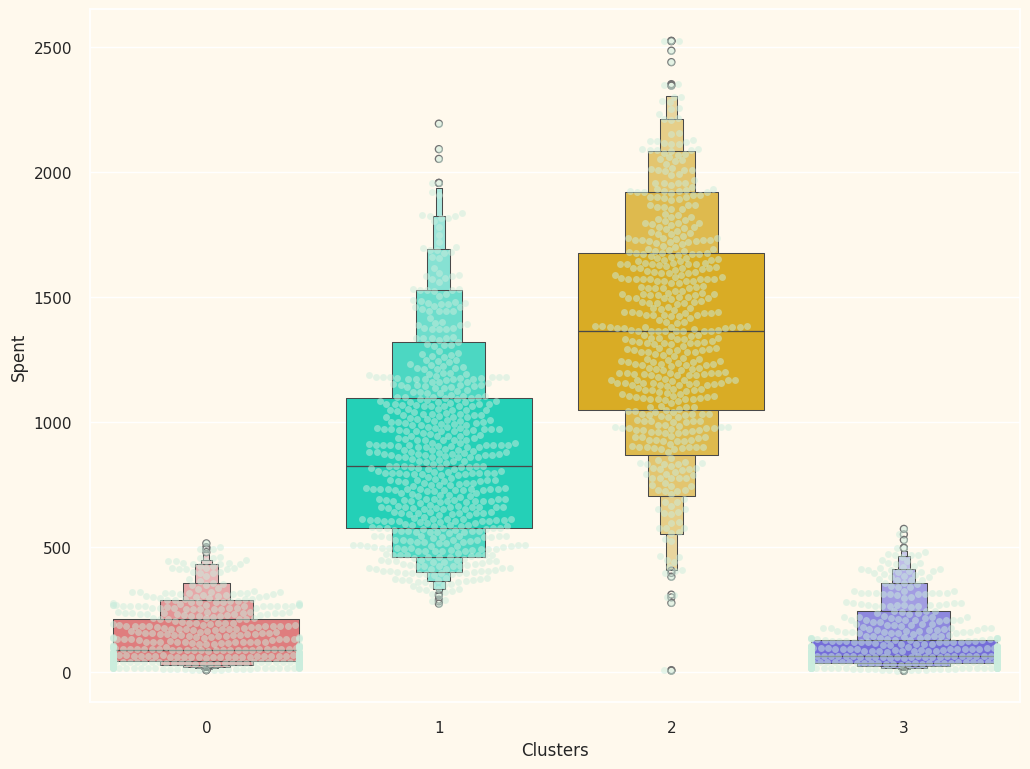

In [ ]:
plt.figure(figsize = (12,9))
pl=sns.swarmplot(x=data["Clusters"], y=data["Spent"], color= "#CBEDDD", alpha=0.5 )
pl=sns.boxenplot(x=data["Clusters"], y=data["Spent"], palette=pal)
plt.show()

## Spending Behavior by Customer Segment
The spending distribution differs significantly across customer segments. Cluster 2 represents the highest-value customers, followed by Cluster 1, while Clusters 0 and 3 show substantially lower spending levels. This suggests that different customer groups should receive different marketing strategies rather than applying the same campaign to all customers.

แล้วเชื่อมกับ action:

Cluster 2: รักษาลูกค้า → VIP / Premium / Loyalty
Cluster 1: เพิ่มมูลค่าต่อคน → Upsell / Cross-sell
Cluster 0: กระตุ้น spending → Family bundle / Promotion
Cluster 3: กระตุ้น conversion → Discount / Retargeting

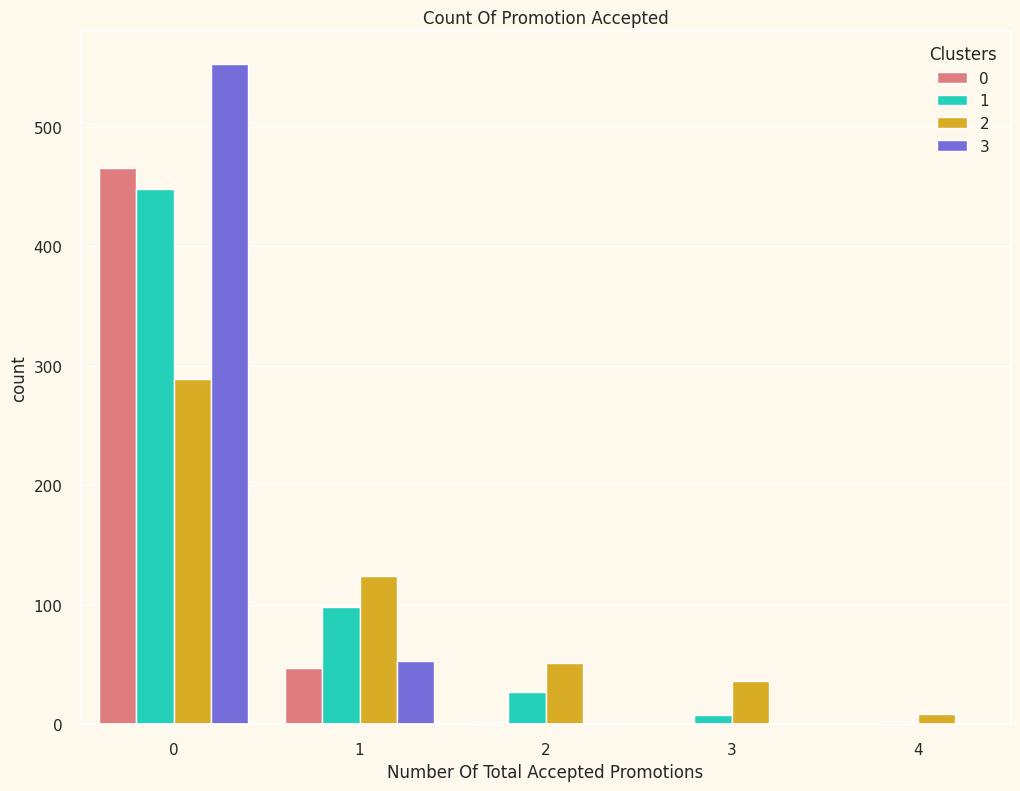

In [ ]:
#Creating a feature to get a sum of accepted promotions
data["Total_Promos"] = data["AcceptedCmp1"]+ data["AcceptedCmp2"]+ data["AcceptedCmp3"]+ data["AcceptedCmp4"]+ data["AcceptedCmp5"]
#Plotting count of total campaign accepted.
plt.figure(figsize = (12,9))
pl = sns.countplot(x=data["Total_Promos"],hue=data["Clusters"], palette= pal)
pl.set_title("Count Of Promotion Accepted")
pl.set_xlabel("Number Of Total Accepted Promotions")
plt.show()

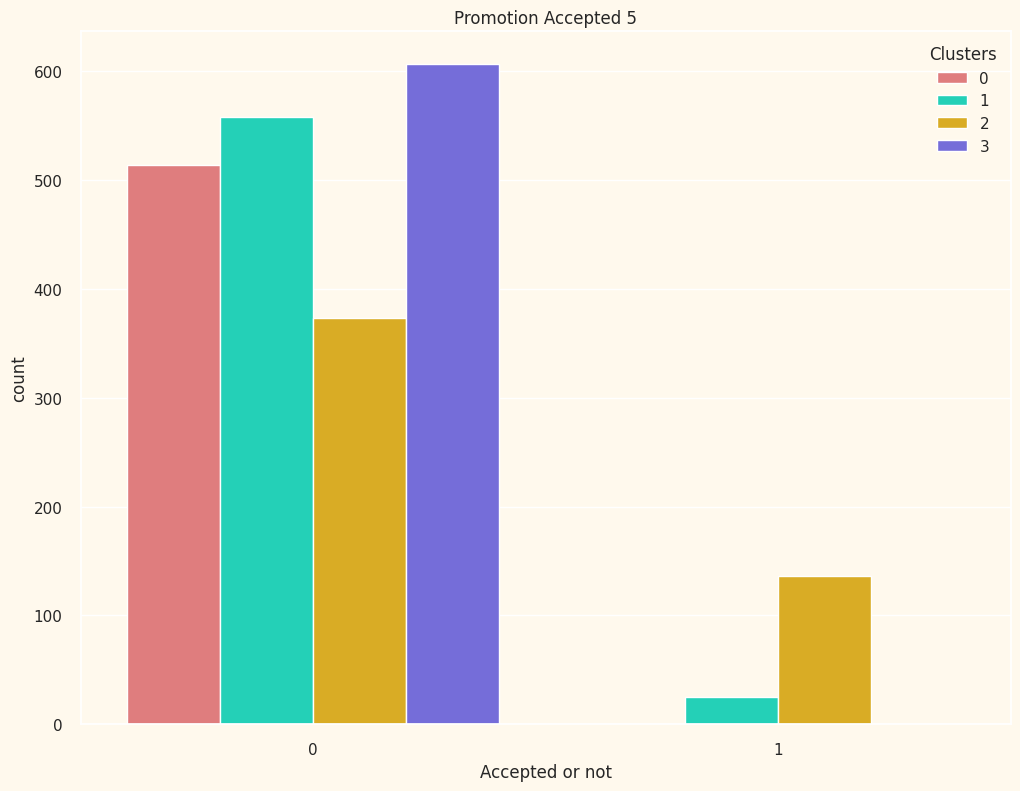

In [ ]:
plt.figure(figsize = (12,9))
pl = sns.countplot(x=data["AcceptedCmp5"],hue=data["Clusters"], palette= pal)
pl.set_title("Promotion Accepted 5")
pl.set_xlabel("Accepted or not")
plt.show()

/tmp/ipykernel_3326/2570238648.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.boxenplot(y=data["NumDealsPurchases"],x=data["Clusters"], palette= pal)


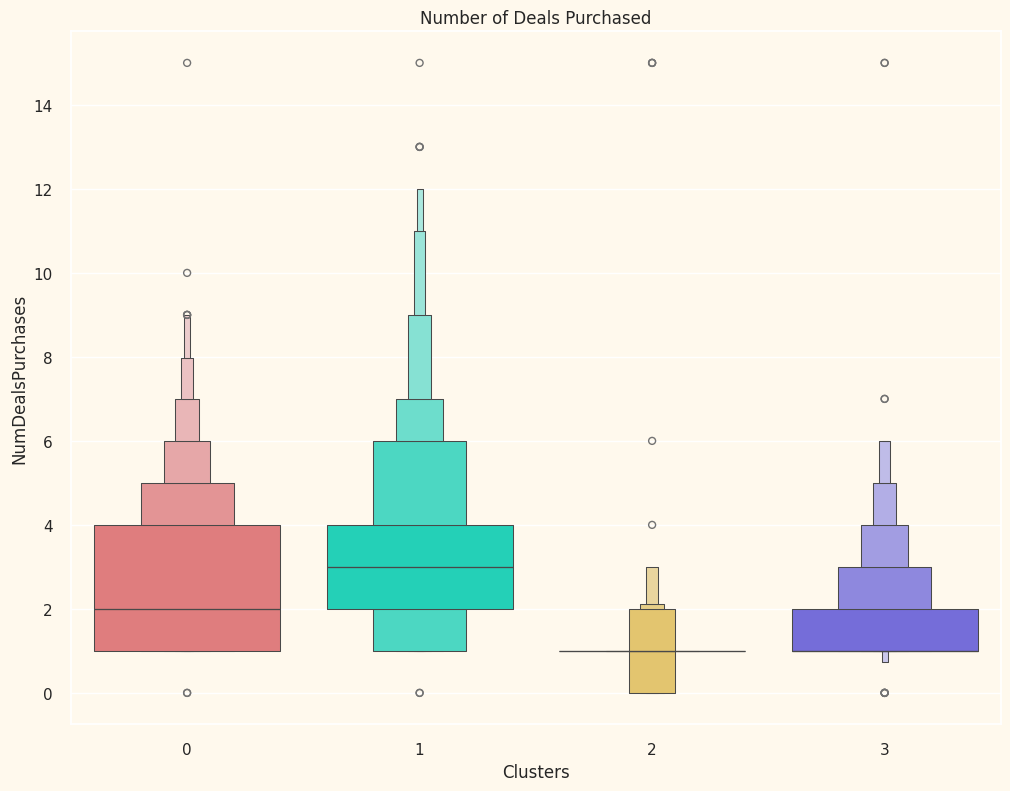

In [ ]:
#Plotting the number of deals purchased
plt.figure(figsize = (12,9))
pl=sns.boxenplot(y=data["NumDealsPurchases"],x=data["Clusters"], palette= pal)
pl.set_title("Number of Deals Purchased")
plt.show()

### Customer Profiles Based on Income and Spending

The customer segments show clear differences in economic value and spending behavior.

- **Cluster 0:** Medium-income customers with relatively low spending.
- **Cluster 1:** Mid-to-high income customers with high spending.
- **Cluster 2:** Highest-income and highest-spending customers.
- **Cluster 3:** Lowest-income customers with relatively low spending.

These differences suggest that customer value varies significantly across segments and that different marketing strategies should be applied to each group.

/tmp/ipykernel_3326/2141744595.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.barplot(y=data["Spent"],x=data["Clusters"], palette= pal)


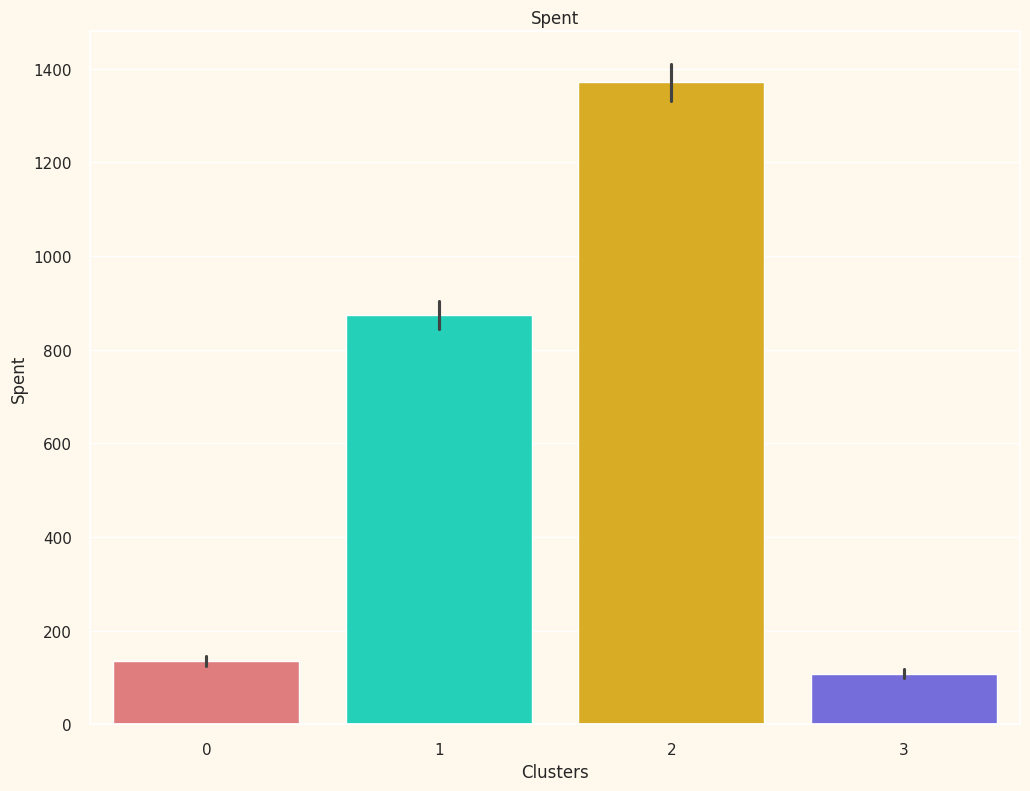

In [ ]:
plt.figure(figsize = (12,9))
pl=sns.barplot(y=data["Spent"],x=data["Clusters"], palette= pal)
pl.set_title("Spent")
plt.show()

In [ ]:
data["numtotal"] = data['NumDealsPurchases'] + data['NumWebPurchases'] + data['NumCatalogPurchases'] + data['NumStorePurchases']

/tmp/ipykernel_3326/354566178.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.barplot(y=data["numtotal"],x=data["Clusters"], palette= pal)


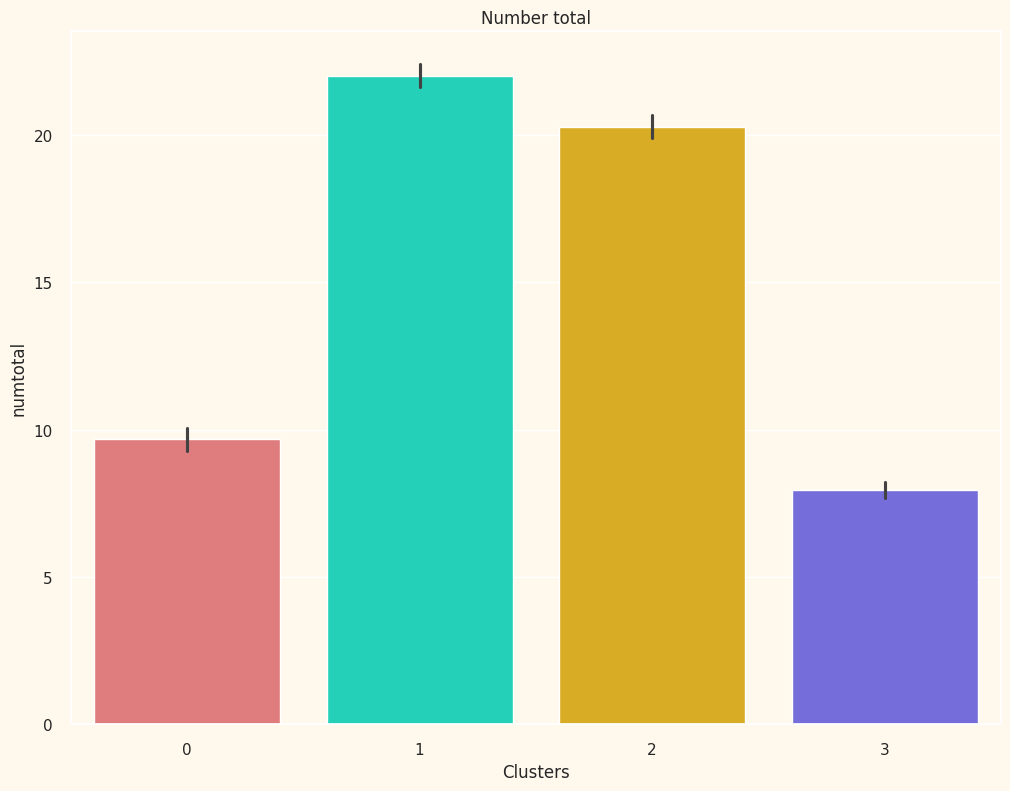

In [ ]:
plt.figure(figsize = (12,9))
pl=sns.barplot(y=data["numtotal"],x=data["Clusters"], palette= pal)
pl.set_title("Number total")
plt.show()

### Online Purchasing Behavior

Customer segments demonstrate different levels of online engagement and purchasing activity.

Cluster 1 shows strong online purchasing activity, while Cluster 3 visits the website frequently but makes relatively fewer online purchases.

This indicates a potential **conversion opportunity** for Cluster 3. Targeted offers, retargeting campaigns, or improvements to the online customer journey could help convert browsing activity into purchases.

/tmp/ipykernel_3326/2073531949.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.barplot(y=data["NumWebPurchases"],x=data["Clusters"], palette= pal)


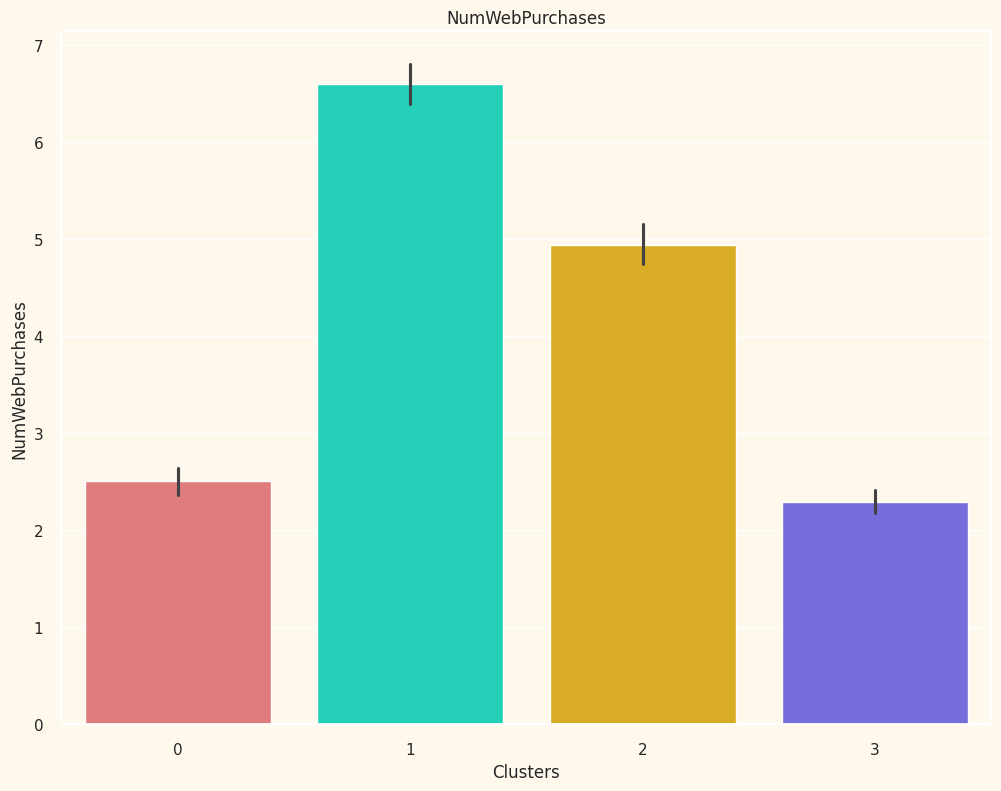

In [ ]:
plt.figure(figsize = (12,9))
pl=sns.barplot(y=data["NumWebPurchases"],x=data["Clusters"], palette= pal)
pl.set_title("NumWebPurchases")
plt.show()

/tmp/ipykernel_3326/2818036359.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.barplot(y=data["NumWebVisitsMonth"],x=data["Clusters"], palette= pal)


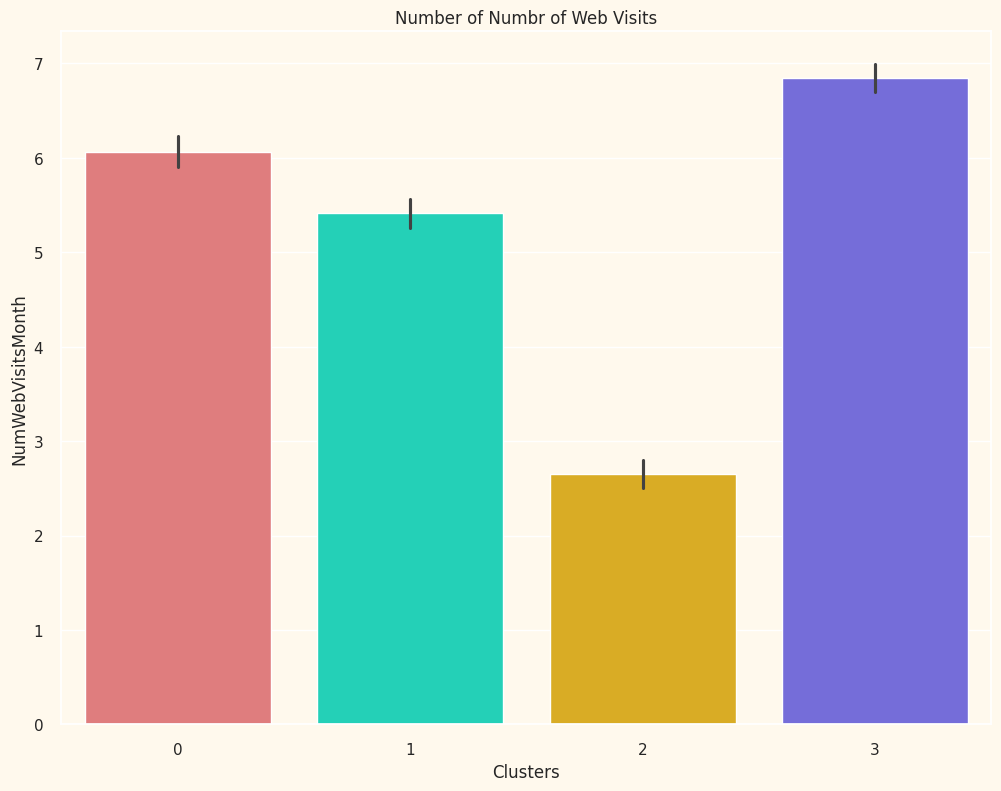

In [ ]:
plt.figure(figsize = (12,9))
pl=sns.barplot(y=data["NumWebVisitsMonth"],x=data["Clusters"], palette= pal)
pl.set_title("Number of Numbr of Web Visits")
plt.show()

### Household Characteristics

Cluster 0 has the largest average family size and the highest number of children among the customer segments.

This suggests that Cluster 0 can be considered a more **family-oriented customer segment**.

Family bundles, value-for-money packages, and household-focused promotions may therefore be more relevant for this group.

/tmp/ipykernel_3326/3131575838.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.barplot(y=data["Family_Size"],x=data["Clusters"], palette= pal)


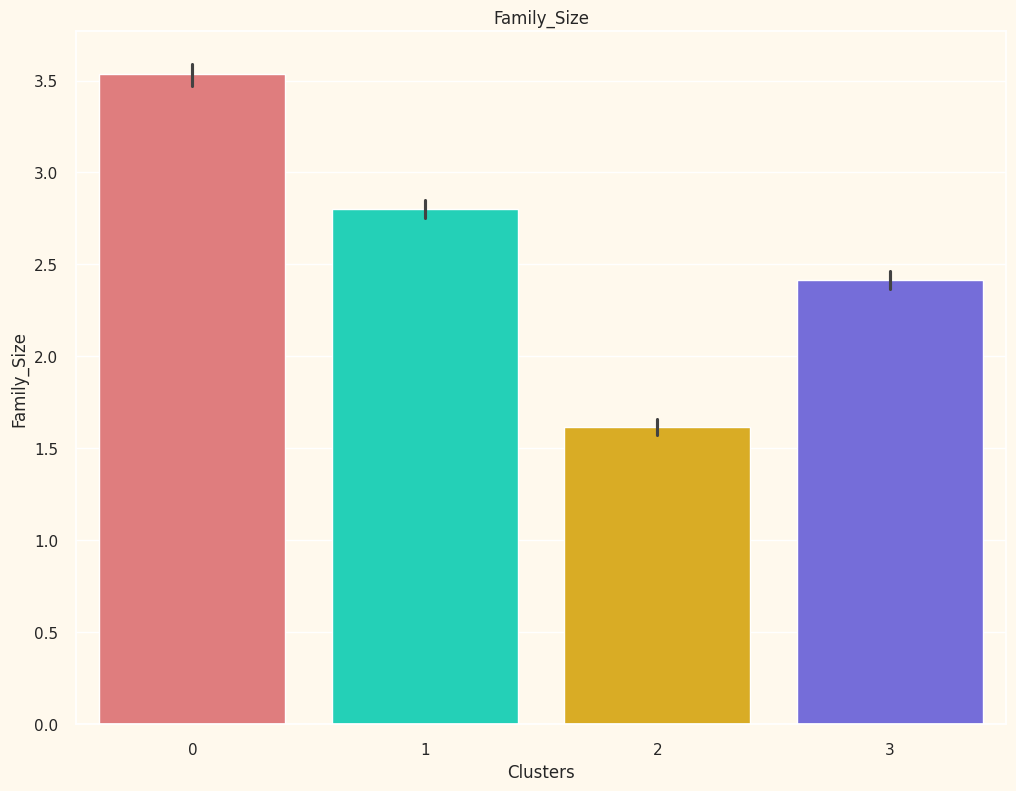

In [ ]:
plt.figure(figsize = (12,9))
pl=sns.barplot(y=data["Family_Size"],x=data["Clusters"], palette= pal)
pl.set_title("Family_Size")
plt.show()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   int64  
 1   Income               2212 non-null   float64
 2   Kidhome              2212 non-null   int64  
 3   Teenhome             2212 non-null   int64  
 4   Recency              2212 non-null   int64  
 5   Wines                2212 non-null   int64  
 6   Fruits               2212 non-null   int64  
 7   Meat                 2212 non-null   int64  
 8   Fish                 2212 non-null   int64  
 9   Sweets               2212 non-null   int64  
 10  Gold                 2212 non-null   int64  
 11  NumDealsPurchases    2212 non-null   int64  
 12  NumWebPurchases      2212 non-null   int64  
 13  NumCatalogPurchases  2212 non-null   int64  
 14  NumStorePurchases    2212 non-null   int64  
 15  NumWebVisitsMonth    2212 non-null   int64 

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

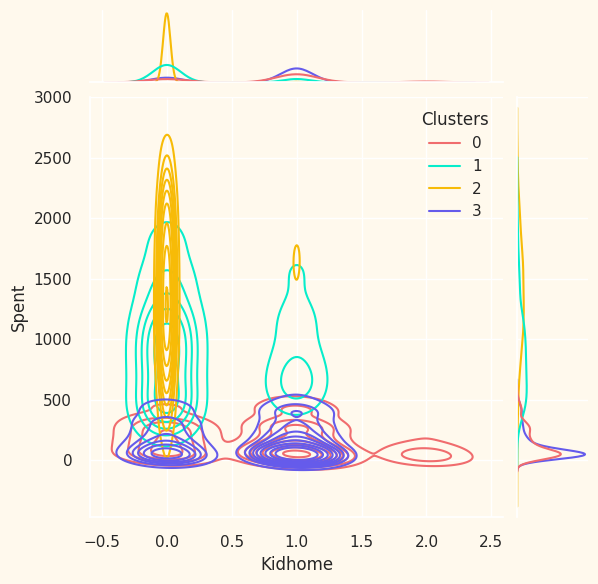

<Figure size 1200x900 with 0 Axes>

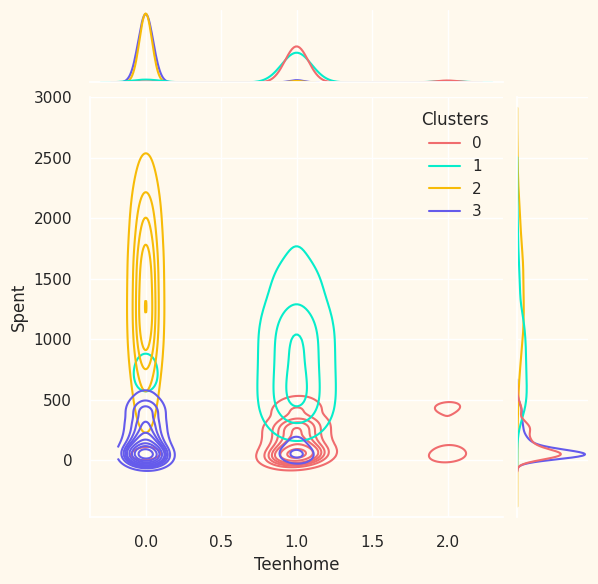

<Figure size 1200x900 with 0 Axes>

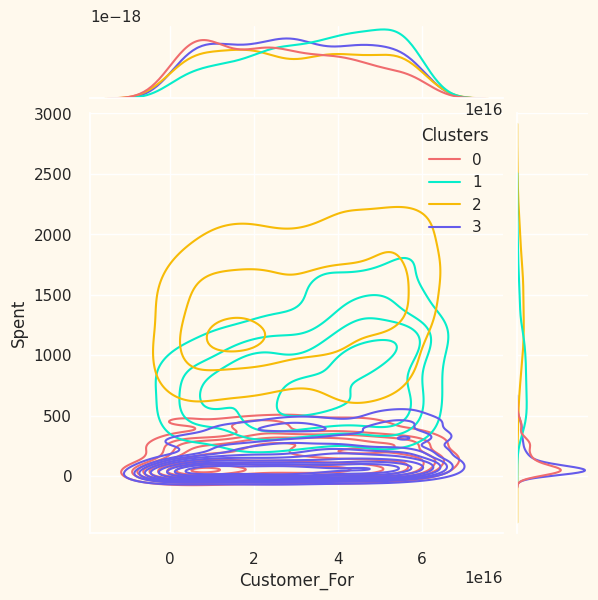

<Figure size 1200x900 with 0 Axes>

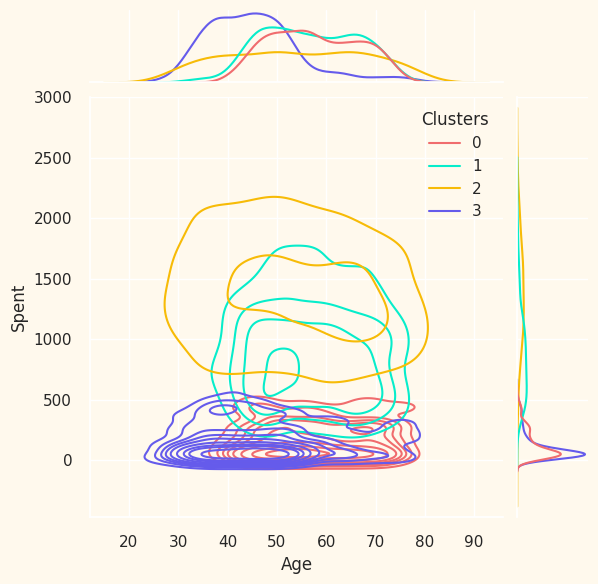

<Figure size 1200x900 with 0 Axes>

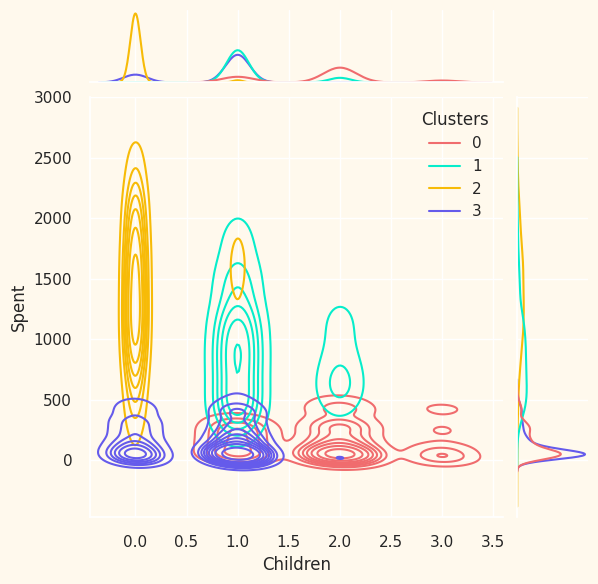

<Figure size 1200x900 with 0 Axes>

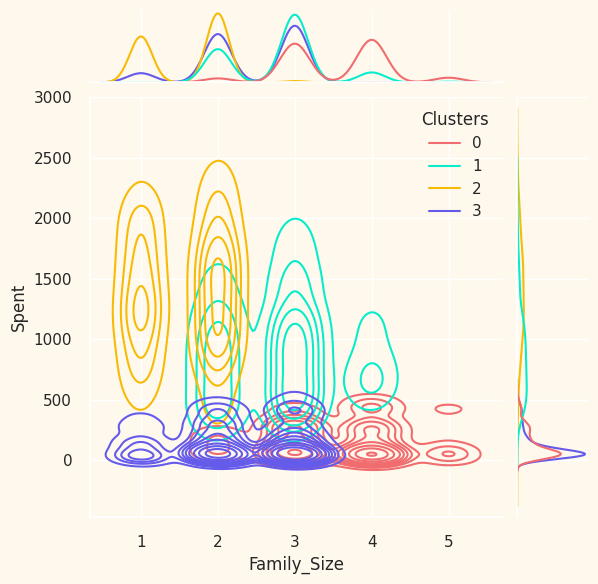

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1883: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(x=self.x, ax=self.ax_marg_x, **kwargs)


<Figure size 1200x900 with 0 Axes>

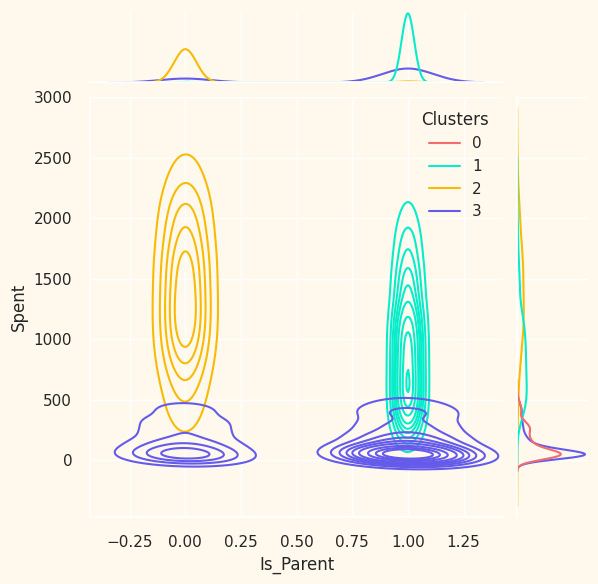

<Figure size 1200x900 with 0 Axes>

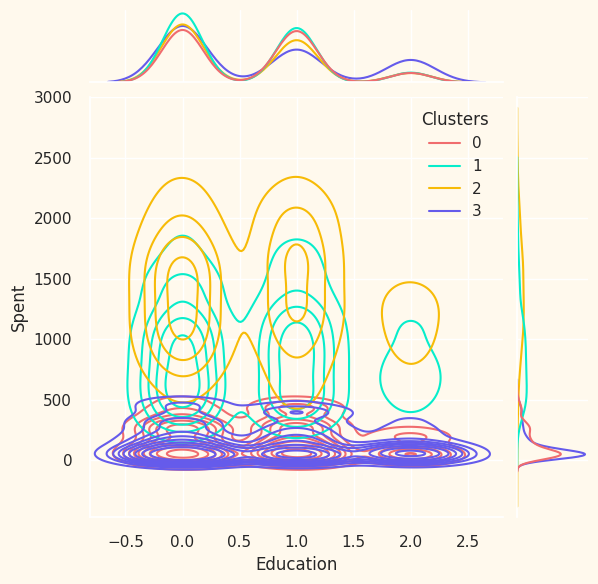

<Figure size 1200x900 with 0 Axes>

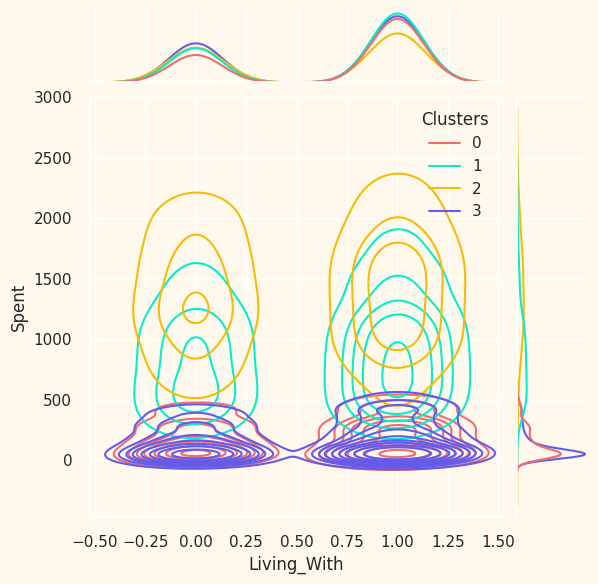

In [ ]:
Personal = [ "Kidhome","Teenhome","Customer_For", "Age", "Children", "Family_Size", "Is_Parent", "Education","Living_With"]
plt.figure(figsize = (12,9))
for i in Personal:
    plt.figure(figsize = (12,9))
    sns.jointplot(x=data[i], y=data["Spent"], hue =data["Clusters"], kind="kde", palette=pal)
    plt.show()

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

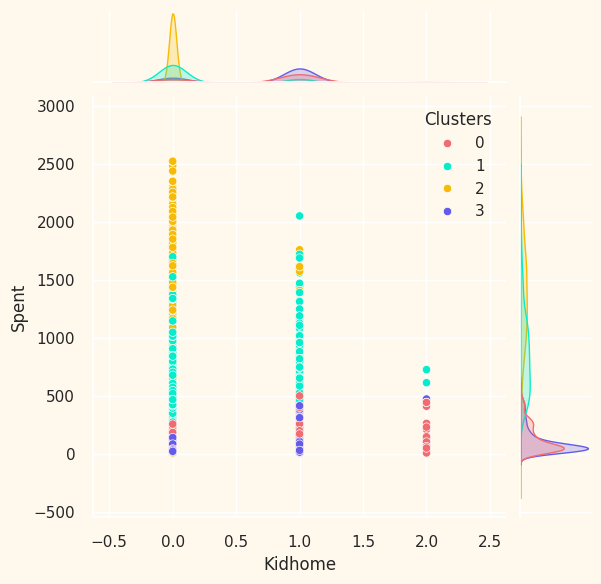

<Figure size 1200x900 with 0 Axes>

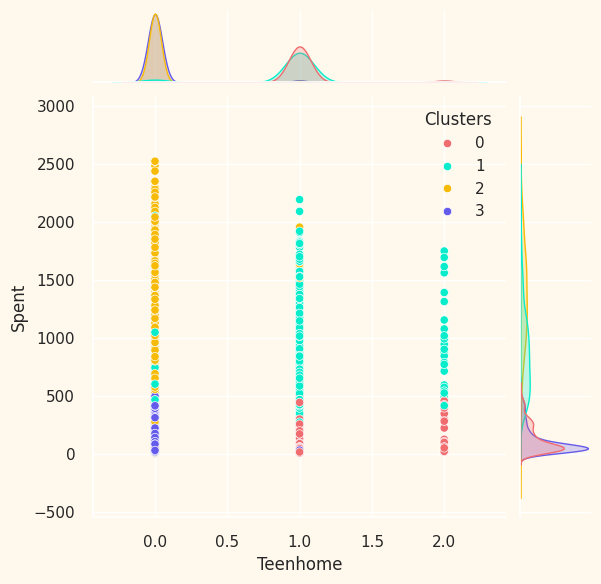

<Figure size 1200x900 with 0 Axes>

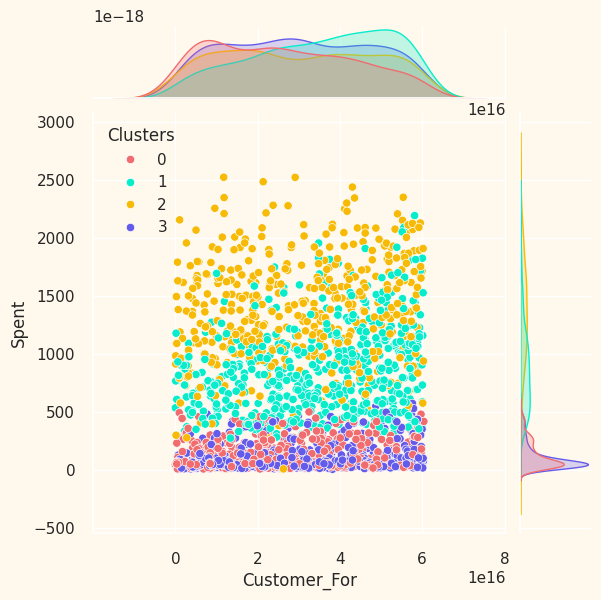

<Figure size 1200x900 with 0 Axes>

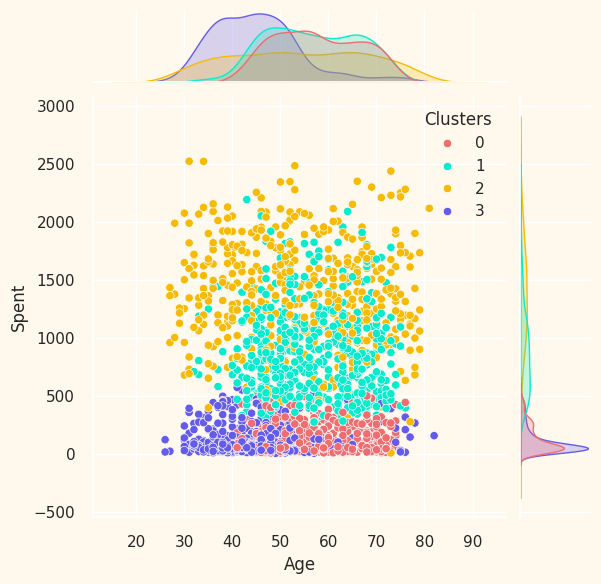

<Figure size 1200x900 with 0 Axes>

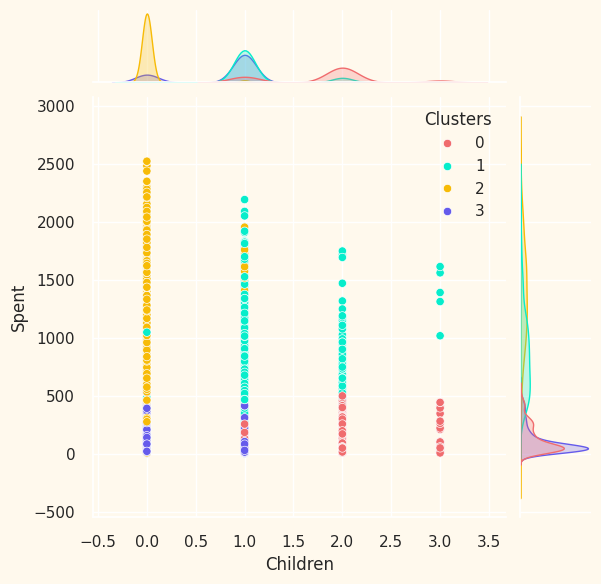

<Figure size 1200x900 with 0 Axes>

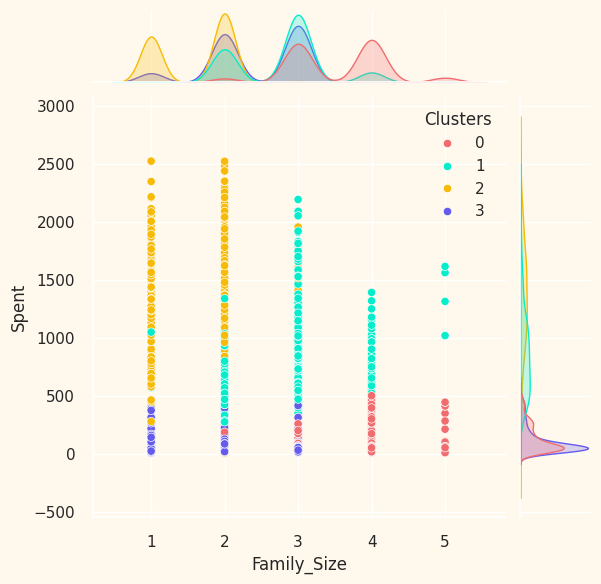

<Figure size 1200x900 with 0 Axes>

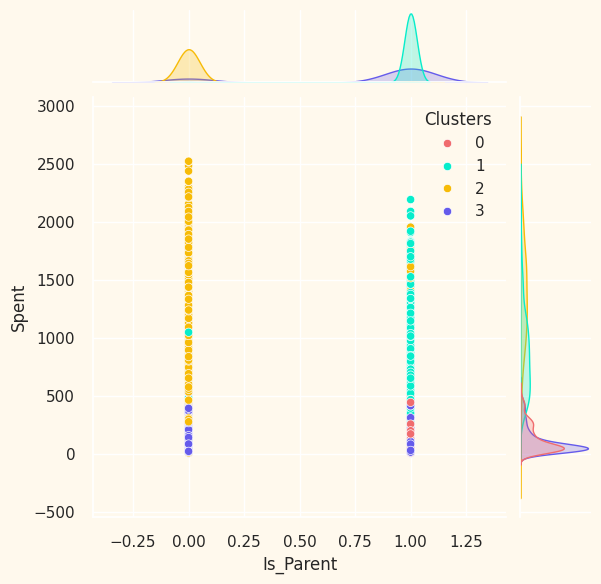

<Figure size 1200x900 with 0 Axes>

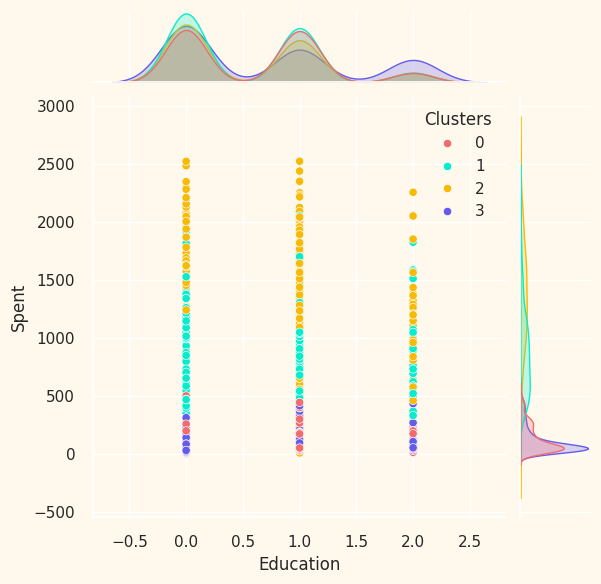

<Figure size 1200x900 with 0 Axes>

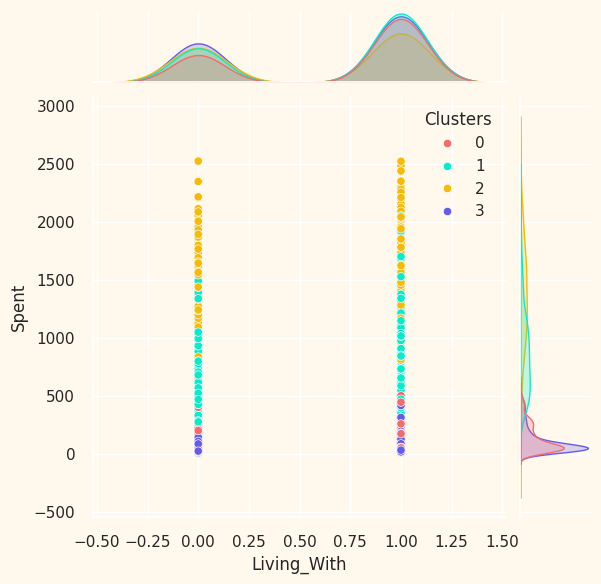

In [ ]:
Personal = [ "Kidhome","Teenhome","Customer_For", "Age", "Children", "Family_Size", "Is_Parent", "Education","Living_With"]
plt.figure(figsize = (12,9))
for i in Personal:
    plt.figure(figsize = (12,9))
    sns.jointplot(x=data[i], y=data["Spent"], hue =data["Clusters"],palette=pal)
    plt.show()

## Conclusion

This project applied **K-Means clustering** to segment customers based on demographic, household, income, and purchasing behavior.

Using the Elbow Method, four customer segments were identified:

- **Cluster 0 — Family-Oriented Low-Spending Customers**
- **Cluster 1 — Active Mid-to-High Value Customers**
- **Cluster 2 — High-Value Customers**
- **Cluster 3 — Low-Value / Low-Engagement Customers**

The analysis demonstrates that customer segmentation can reveal meaningful differences in spending levels, purchasing channels, online engagement, and household characteristics.

Rather than applying the same marketing strategy to all customers, businesses can use these insights to develop more targeted approaches such as loyalty programs, premium offers, family-focused promotions, and conversion campaigns.

## Limitations & Next Steps

This analysis provides an initial customer segmentation framework. Further improvements could include:

- Evaluating cluster quality using additional metrics such as Silhouette Score.
- Testing different clustering algorithms and comparing the results.
- Incorporating additional behavioral or transactional data.
- Tracking how customer segments change over time.
- Measuring the actual response of each segment to targeted marketing campaigns.
- Developing a dashboard to monitor customer segments and key business metrics.

These improvements could help transform the segmentation model from an exploratory analysis into a practical customer analytics tool for marketing decision-making.